# Meteorological Indicators, Exposure, and EF Rating in U.S. Tornadoes, 2010–2025

## 1. Study Overview

This study examines how radar indicators, tornado characteristics, and land-cover
exposure proxies relate to recorded EF ratings for U.S. tornadoes from 2010–2025.
Retrospective and onset feature views support the analysis, alongside controlled
neural-network experiments.

- **Primary question:** How do meteorology, tornado characteristics, and exposure
  relate to final EF rating?
- **Secondary question:** How well can final EF rating be estimated using
  features eligible by reported onset?
- **Modeling question:** How do learning rate, SGD, L2 regularization, and
  dropout affect training, generalization, and overfitting?

EF is a damage-based rating, not a direct wind measurement.

## 2. Setup

In [1]:
# Python 3.12+. Uncomment to install dependencies in this notebook kernel.
# %pip install geopandas joblib kagglehub matplotlib numpy pandas pyarrow scikit-learn jinja2 ipykernel

import hashlib
import json
import os
import random
import textwrap
from collections.abc import Mapping, Sequence
from importlib.metadata import version
from pathlib import Path
from typing import TypedDict

# Paths are relative to the notebook kernel's working folder.
BASE_DIR = Path.cwd()

os.environ.setdefault("MPLCONFIGDIR", str(BASE_DIR / "data/.cache/matplotlib"))

import geopandas as gpd
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
from numpy.typing import NDArray
from shapely.geometry import Polygon
from shapely.geometry import box as geometry_box
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Reset these seeds and the TensorFlow seed before each later training run.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
DATASET = "jakevanslyke/us-tornado-data-2010-2025/versions/8"
RELEASE = "v2.2.1"
MANIFEST_SHA256 = "9a4ec9b89cbf43cdfa88db26360881aab84437fee619f1b98e1fb04a338f8feb"
DATA_DIR = BASE_DIR / "data"
SOURCE_DIR = DATA_DIR / "source/v8"
DERIVED_DIR = DATA_DIR / "derived"
RESULTS_DIR = DATA_DIR / "results"
AUDIT_DIR = RESULTS_DIR / "audit"
FIGURE_DIR = BASE_DIR / "assets/figures"
TABLE_DIR = BASE_DIR / "assets/tables"

for directory in (SOURCE_DIR, DERIVED_DIR, AUDIT_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ML_FILES = (
    "ml/events_onset.parquet",
    "ml/events_retrospective.parquet",
    "ml/feature_dictionary.json",
)

MAP_FILES = (
    "analysis/county_boundaries.parquet",
    "analysis/event_areas.parquet",
    "analysis/tornado_footprints.parquet",
)

SPLIT_ORDER = ["train", "validation", "test"]
SPLIT_FRACTIONS = np.array([0.70, 0.15, 0.15])
SPLIT_CANDIDATES = 512
CLASS_NAMES = [f"EF{i}" for i in range(6)]
N_CLASSES = len(CLASS_NAMES)
EVALUATION_SETTINGS = {
    "class_labels": list(range(N_CLASSES)),
    "selection_metric": "validation macro-F1",
    "metrics": [
        "accuracy",
        "cross_entropy",
        "macro_f1",
        "per_class_precision",
        "per_class_recall",
        "per_class_f1",
        "class_support",
        "confusion_matrix",
        "ef_category_mae",
        "within_one_category_accuracy",
    ],
    "prediction_rule": "argmax of six class probabilities",
    "undefined_class_metric": "zero_division=0; explicitly report absent classes and support",
    "evaluation_weighting": "unweighted validation and test metrics",
    "test_policy": "evaluate each final selected task model once; never select using test scores",
}

In [3]:
EF_ORDER = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "Unknown"]
EF_COLORS = dict(
    zip(
        EF_ORDER,
        ["#F2C94C", "#F29E38", "#ED6A32", "#D93632", "#AD203E", "#650026", "#999999"],
        strict=True,
    )
)
ACCENT = "#0072B2"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "svg.fonttype": "none",
    }
)

In [4]:
def show_saved(description: str, *paths: Path, status: str = "Saved") -> None:
    """Show links only after the files exist."""
    links = []
    for path in map(Path, paths):
        assert path.is_file(), path
        relative = path.relative_to(BASE_DIR).as_posix()
        links.append(f"[{path.name}]({relative})")
    display(Markdown(f"**{status} — {description}:** " + " · ".join(links)))


def save_json(value: object, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


def save_figure(fig: Figure, name: str, directory: Path = FIGURE_DIR) -> None:
    for extension in ("png", "svg"):
        path = directory / f"{name}.{extension}"
        fig.savefig(path, bbox_inches="tight")
        if extension == "svg":
            path.write_text(
                "\n".join(line.rstrip() for line in path.read_text().splitlines()) + "\n"
            )


def save_table(
    frame: pd.DataFrame,
    name: str,
    title: str,
    *,
    caption: str,
    formats: Mapping[str, str] | None = None,
    note: str | None = None,
    width: float = 9,
    results_dir: Path = AUDIT_DIR,
) -> None:
    """Save numeric CSV plus a legible, consistently styled table image."""
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)
    frame.to_csv(results_dir / f"{name}.csv", index=False)
    shown = frame.copy()
    for column, pattern in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value, pattern=pattern: "—" if pd.isna(value) else format(value, pattern)
        )
    shown = shown.fillna("—").astype(str)
    note_lines = textwrap.wrap(note, width=110) if note else []
    height = 0.34 * (len(frame) + 1.5) + 0.65 + 0.18 * len(note_lines)
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")
    fig.text(0.03, 1 - 0.22 / height, title, fontsize=12, weight="bold", va="top")
    headers = [textwrap.fill(str(c), width=22) for c in frame.columns]
    column_widths = np.array(
        [
            max(max(map(len, header.splitlines())), shown[column].str.len().max()) + 3
            for column, header in zip(frame.columns, headers, strict=True)
        ],
        dtype=float,
    )
    table = ax.table(
        cellText=shown.values.tolist(),
        colLabels=headers,
        colWidths=column_widths / column_widths.sum(),
        cellLoc="right",
        colLoc="left",
        bbox=Bbox.from_bounds(0, 0, 1, 1),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D6DEE5")
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor("#E7EEF4")
            cell.set_text_props(weight="bold", color="#172B3A")
            cell.set_height(cell.get_height() * 1.5)
        else:
            cell.set_facecolor("#F6F8FA" if row % 2 == 0 else "white")
        if col == 0:
            cell.set_text_props(ha="left")
    if note_lines:
        fig.text(0.03, 0.03, "\n".join(note_lines), fontsize=9, color="#46535F")
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=1 - 0.55 / height,
        bottom=(0.16 + 0.22 * len(note_lines)) / height,
    )
    save_figure(fig, name, TABLE_DIR)
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    show_saved(
        title, TABLE_DIR / f"{name}.png", TABLE_DIR / f"{name}.svg", results_dir / f"{name}.csv"
    )


def file_sha256(path: Path) -> str:
    with Path(path).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def show_figure(fig: Figure, name: str, caption: str) -> None:
    """Save, display, caption, and link a finished analysis figure."""
    save_figure(fig, name)
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    show_saved("figure", FIGURE_DIR / f"{name}.png", FIGURE_DIR / f"{name}.svg")

In [5]:
# Shared data-preparation helpers.
class HoldoutSplit(TypedDict):
    candidate: int
    score: float
    indices: list[NDArray[np.int64]]


def stratified_group_holdout(
    labels: NDArray[np.int64],
    groups: NDArray[np.object_],
    *,
    fractions: NDArray[np.float64],
    class_count: int,
    seed: int,
    candidates: int,
) -> HoldoutSplit:
    """Balance class allocations and row counts across seeded whole-group splits."""
    class_totals = np.bincount(labels, minlength=class_count)
    best: HoldoutSplit | None = None
    generator = GroupShuffleSplit(n_splits=candidates, test_size=0.30, random_state=seed)
    for trial, (training, held_out) in enumerate(generator.split(labels, labels, groups)):
        validation, test = next(
            GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed + trial).split(
                held_out, labels[held_out], groups[held_out]
            )
        )
        indices = [training, held_out[validation], held_out[test]]
        counts = np.array([np.bincount(labels[index], minlength=class_count) for index in indices])
        complete = bool((counts > 0).all())
        # Selection uses labels/group sizes only, never features or model performance.
        class_error = np.mean((counts / class_totals - fractions[:, None]) ** 2)
        size_error = np.mean((counts.sum(axis=1) / len(labels) - fractions) ** 2)
        score = float(class_error + size_error)
        if complete and (best is None or score < best["score"]):
            best = {"candidate": trial, "score": score, "indices": indices}
    if best is None:
        raise ValueError(
            "No group-disjoint allocation supports all six classes. Review the split design."
        )
    return best


def encode_predictors(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    log_columns: list[str],
) -> pd.DataFrame:
    """Apply fixed calendar and log transforms without estimating parameters."""
    encoded = frame[columns].copy()
    encoded["hour_utc"] = frame["onset_utc"].dt.hour.astype(float)
    for column, period, offset in [("month", 12, 1), ("hour_utc", 24, 0)]:
        angle = 2 * np.pi * (encoded.pop(column).astype(float) - offset) / period
        encoded[f"{column}_sin"] = np.sin(angle)
        encoded[f"{column}_cos"] = np.cos(angle)
    for column in set(log_columns) & set(columns):
        assert encoded[column].dropna().ge(0).all(), column
        encoded[column] = np.log1p(encoded[column])
    return encoded.astype(float)


def prepare_inputs(
    split_frames: Mapping[str, pd.DataFrame],
    labels: Mapping[str, pd.Series],
) -> tuple[Pipeline, dict[str, pd.DataFrame]]:
    """Fit on training rows, then transform each split without refitting."""
    train_features = split_frames["train"]
    assert not train_features.isna().all().any(), "A training predictor is entirely missing."
    preprocessor = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )
    preprocessor.fit(train_features)
    feature_names = preprocessor.get_feature_names_out().tolist()
    prepared_splits = {}
    for split, frame in split_frames.items():
        prepared = pd.DataFrame(
            preprocessor.transform(frame).astype("float32"),
            index=frame.index,
            columns=feature_names,
        )
        assert prepared.index.equals(labels[split].index)
        assert np.isfinite(prepared.to_numpy()).all()
        prepared_splits[split] = prepared
    imputer, scaler = preprocessor["imputer"], preprocessor["scaler"]
    assert scaler.n_samples_seen_ == len(train_features)
    np.testing.assert_allclose(imputer.statistics_, train_features.median().to_numpy())
    np.testing.assert_allclose(prepared_splits["train"].mean(), 0, atol=1e-5)
    return preprocessor, prepared_splits

In [6]:
# Geographic helpers use projected coordinates; the modeling cohort is untouched.
def geographic_bins(
    events: gpd.GeoDataFrame,
    boundaries: gpd.GeoDataFrame,
    *,
    hex_width_m: float,
) -> tuple[gpd.GeoDataFrame, tuple[float, float, float, float]]:
    """Count event starts in equal-area hexagons and return their map extent."""
    bounds = np.vstack([boundaries.total_bounds, events.total_bounds])
    low = bounds[:, :2].min(axis=0) - hex_width_m
    high = bounds[:, 2:].max(axis=0) + hex_width_m
    step = np.array([hex_width_m, np.sqrt(3) * hex_width_m])
    origin = np.floor(low / step) * step
    grid = np.ceil((high - origin) / step).astype(int)
    upper = origin + grid * step
    extent = (float(origin[0]), float(upper[0]), float(origin[1]), float(upper[1]))
    scratch, axis = plt.subplots()
    counts = axis.hexbin(
        events.geometry.x,
        events.geometry.y,
        gridsize=(int(grid[0]), int(grid[1])),
        extent=extent,
        mincnt=1,
    )
    frequencies = counts.get_array()
    assert frequencies is not None
    centers = np.asarray(counts.get_offsets())
    vertices = counts.get_paths()[0].vertices
    cells = gpd.GeoDataFrame(
        {
            "region": "Contiguous U.S.",
            "center_x_m": centers[:, 0],
            "center_y_m": centers[:, 1],
            "events": frequencies.astype(int),
        },
        geometry=[Polygon(vertices + center) for center in centers],
        crs=events.crs,
    )
    plt.close(scratch)
    assert cells.events.sum() == len(events)
    np.testing.assert_allclose(cells.area, np.sqrt(3) / 2 * hex_width_m**2, rtol=1e-7)

    return cells, extent


def plot_geographic_distribution(
    events: gpd.GeoDataFrame,
    boundaries: gpd.GeoDataFrame,
    cells: gpd.GeoDataFrame,
    extent: tuple[float, float, float, float],
    *,
    class_names: Sequence[str],
    colors: Mapping[str, str],
) -> Figure:
    """Overlay six-class event locations on a separate frequency scale."""
    # Frequency has its own scale; point opacity only softens overlap.
    breaks = [1, 5, 10, 20, 40, max(41, int(cells.events.max()) + 1)]
    frequency_labels = ["1–4", "5–9", "10–19", "20–39", "40+"]
    cmap = ListedColormap(plt.get_cmap("Greys")(np.linspace(0.10, 0.45, 5)))
    norm = BoundaryNorm(breaks, cmap.N, clip=True)
    fig, ax = plt.subplots(figsize=(12, 8), layout="constrained")
    boundaries.plot(ax=ax, color="#FAFAFA", edgecolor="none")
    cells.plot(ax=ax, column="events", cmap=cmap, norm=norm, edgecolor="none")
    boundaries.boundary.plot(ax=ax, color="#89939C", linewidth=0.45)
    mapped_known = 0
    for rating, label in enumerate(class_names):
        selected = events.loc[events[TARGET].eq(rating)]
        ax.scatter(
            selected.geometry.x,
            selected.geometry.y,
            s=6,
            alpha=0.70,
            color=colors[label],
            linewidths=0,
            zorder=3 + rating,
        )
        mapped_known += len(selected)
    assert mapped_known == int(events.target_known.sum())
    ax.set(xlim=extent[:2], ylim=extent[2:])
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title("Recorded tornado frequency and EF rating, 2010–2025", pad=14)
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", markersize=6, color=colors[label], label=label)
            for label in class_names
        ],
        loc="lower left",
        frameon=False,
        ncol=3,
        title="Final EF rating",
    )
    bar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.65,
        pad=0.02,
        aspect=40,
    )
    bar.set_ticks(
        ((np.asarray(breaks[:-1]) + np.asarray(breaks[1:])) / 2).tolist(), labels=frequency_labels
    )
    bar.set_label("All recorded events per 50-km hexagon")
    return fig

## 3. Data

[US Tornado Data, 2010–2025](https://www.kaggle.com/datasets/jakevanslyke/us-tornado-data-2010-2025/versions/8)
provides matching retrospective and onset tables. Check their consistency and summarize
**class balance and geographic distribution**, retaining unknown ratings in the audit.
A compact missingness summary accompanies the saved predictor-level counts.

Exposure initially means retrospective land-cover measures. Missing radar maxima can
reflect no qualifying detection; missing warning lead time can reflect no active warning.
Completed collection jobs do not guarantee usable observations. Maps show the contiguous
U.S.; the modeling cohort retains all regions.

### Download

In [7]:
def ensure_source_file(relative_path: str, expected_sha256: str) -> Path:
    destination = SOURCE_DIR / relative_path
    # Reuse local files; output_dir bypasses the global Kaggle cache.
    if not destination.is_file():
        kagglehub.dataset_download(DATASET, path=relative_path, output_dir=str(SOURCE_DIR))
    actual = file_sha256(destination)
    if actual != expected_sha256:
        raise ValueError(
            f"Checksum mismatch for {relative_path}. Inspect the local file and "
            "release before removing it and rerunning the download cell."
        )
    return destination


manifest_path = ensure_source_file("release_manifest.json", MANIFEST_SHA256)
manifest = json.loads(manifest_path.read_text())
assert manifest["version"] == RELEASE
release_files = {entry["path"]: entry for entry in manifest["files"]}

verified_files = []
for relative_path in (*ML_FILES, *MAP_FILES):
    entry = release_files[relative_path]
    path = ensure_source_file(relative_path, entry["sha256"])
    assert path.stat().st_size == entry["bytes"], relative_path
    verified_files.append(
        {
            "path": relative_path,
            "bytes": path.stat().st_size,
            "sha256": entry["sha256"],
        }
    )

save_json(
    {
        "dataset_handle": DATASET,
        "dataset_url": f"https://www.kaggle.com/datasets/{DATASET}",
        "release": RELEASE,
        "source_code_commit": manifest["code_commit"],
        "release_manifest_sha256": MANIFEST_SHA256,
        "files": verified_files,
    },
    SOURCE_DIR / "provenance.json",
)

show_saved(
    "source files (downloaded or reused)",
    SOURCE_DIR / "release_manifest.json",
    *(SOURCE_DIR / name for name in (*ML_FILES, *MAP_FILES)),
    status="Verified",
)
show_saved("data source and file verification", SOURCE_DIR / "provenance.json")

**Verified — source files (downloaded or reused):** [release_manifest.json](data/source/v8/release_manifest.json) · [events_onset.parquet](data/source/v8/ml/events_onset.parquet) · [events_retrospective.parquet](data/source/v8/ml/events_retrospective.parquet) · [feature_dictionary.json](data/source/v8/ml/feature_dictionary.json) · [county_boundaries.parquet](data/source/v8/analysis/county_boundaries.parquet) · [event_areas.parquet](data/source/v8/analysis/event_areas.parquet) · [tornado_footprints.parquet](data/source/v8/analysis/tornado_footprints.parquet)

**Saved — data source and file verification:** [provenance.json](data/source/v8/provenance.json)

### Load data

In [8]:
onset = pd.read_parquet(SOURCE_DIR / "ml/events_onset.parquet")
retrospective = pd.read_parquet(SOURCE_DIR / "ml/events_retrospective.parquet")
spec = json.loads((SOURCE_DIR / "ml/feature_dictionary.json").read_text())

ID, TARGET, GROUP = spec["id"], spec["target"], spec["group"]
tables = {"Onset": onset, "Retrospective": retrospective}
# Use the dictionary allowlists; numeric metadata is not a predictor.
predictors = {
    "Onset": spec["onset_predictor_columns"],
    "Retrospective": spec["retrospective_predictor_columns"],
}

### Validation

In [9]:
assert spec["schema_version"] == 2
expected_rows = manifest["source_verification"]["counts"]["spc_tracks"]
for view, frame in tables.items():
    assert len(frame) == expected_rows, view
    assert frame[ID].notna().all() and frame[ID].is_unique, view
    assert frame[GROUP].notna().all(), view
    assert frame["target_known"].notna().all(), view
    assert frame["target_known"].eq(frame[TARGET].notna()).all(), view
    assert frame[TARGET].dropna().isin(range(6)).all(), view
    assert frame["year"].between(manifest["start_year"], manifest["end_year"]).all()
    assert frame["onset_utc"].notna().all(), view
    assert frame["prediction_cutoff_utc"].eq(frame["onset_utc"]).all(), view
    columns = predictors[view]
    assert len(columns) == len(set(columns)), view
    assert set(columns).issubset(frame.columns), view
    assert all(
        spec["columns"][c]["role"] in {"onset_predictor_candidate", "retrospective_candidate"}
        for c in columns
    ), view
    numeric = frame[columns].select_dtypes(include="number")
    assert not np.isinf(numeric.to_numpy(dtype=float, na_value=np.nan)).any(), view

assert set(predictors["Onset"]).issubset(predictors["Retrospective"])
assert not any(c.startswith("post_") for c in predictors["Onset"])
assert all(spec["columns"][c]["eligible_for_conditional_onset"] for c in predictors["Onset"])
assert all(spec["columns"][c]["available_by_onset"] is None for c in predictors["Onset"])
pd.testing.assert_frame_equal(
    onset.set_index(ID).sort_index(),
    retrospective.set_index(ID).sort_index()[onset.columns.drop(ID)],
)

### Data summary

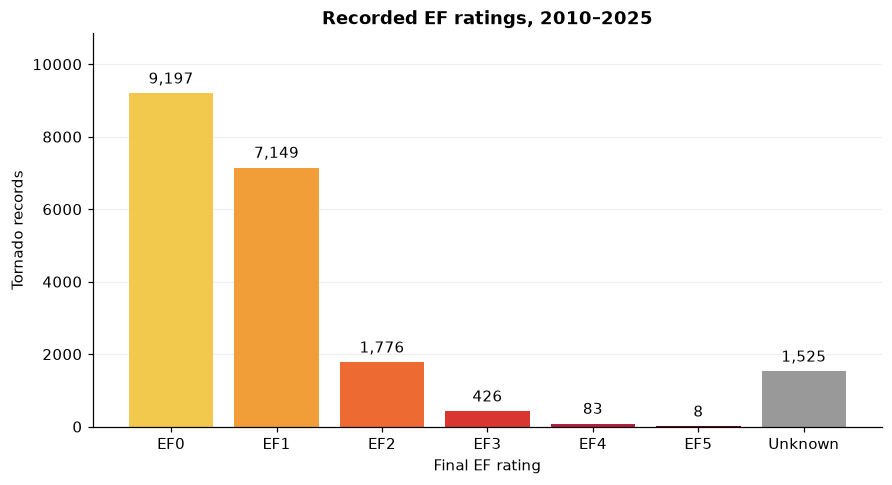

**Figure 1.** Distribution of recorded EF ratings, 2010–2025.

**Saved — figure:** [fig_01_class_distribution.png](assets/figures/fig_01_class_distribution.png) · [fig_01_class_distribution.svg](assets/figures/fig_01_class_distribution.svg)

In [10]:
rating_labels = onset[TARGET].map({i: f"EF{i}" for i in range(6)}).fillna("Unknown")
class_counts = rating_labels.value_counts().reindex(EF_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
bars = ax.bar(EF_ORDER, class_counts, color=[EF_COLORS[c] for c in EF_ORDER])
ax.bar_label(bars, labels=[f"{n:,}" for n in class_counts], padding=4, fontsize=10)
ax.set(title="Recorded EF ratings, 2010–2025", ylabel="Tornado records", xlabel="Final EF rating")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_01_class_distribution",
    "**Figure 1.** Distribution of recorded EF ratings, 2010–2025.",
)

In [11]:
missingness_rows = []
for view, frame in tables.items():
    missing = frame[predictors[view]].isna().sum()
    missingness_rows.extend(
        {
            "view": view,
            "feature": column,
            "missing_events": int(count),
            "total_events": len(frame),
            "missing_percent": 100 * count / len(frame),
        }
        for column, count in missing.items()
    )

missingness = pd.DataFrame(missingness_rows)
missingness.to_csv(AUDIT_DIR / "feature_missingness.csv", index=False)

missingness_summary = missingness.groupby("view", sort=False).agg(
    predictors=("feature", "size"),
    incomplete_predictors=("missing_events", lambda counts: int(counts.gt(0).sum())),
    largest_missing_percent=("missing_percent", "max"),
)
display(
    Markdown(
        f"**Data checks passed:** {len(onset):,} matching events per view; "
        f"{onset.target_known.sum():,} known ratings and {(~onset.target_known).sum():,} unknown ratings."
    )
)
display(missingness_summary.style.format({"largest_missing_percent": "{:.1f}%"}))
show_saved("missingness for each predictor in both views", AUDIT_DIR / "feature_missingness.csv")

**Data checks passed:** 20,164 matching events per view; 18,639 known ratings and 1,525 unknown ratings.

,predictors,incomplete_predictors,largest_missing_percent
view,,,
Onset,15,6,65.8%
Retrospective,32,15,65.8%


**Saved — missingness for each predictor in both views:** [feature_missingness.csv](data/results/audit/feature_missingness.csv)

### Geographic coverage

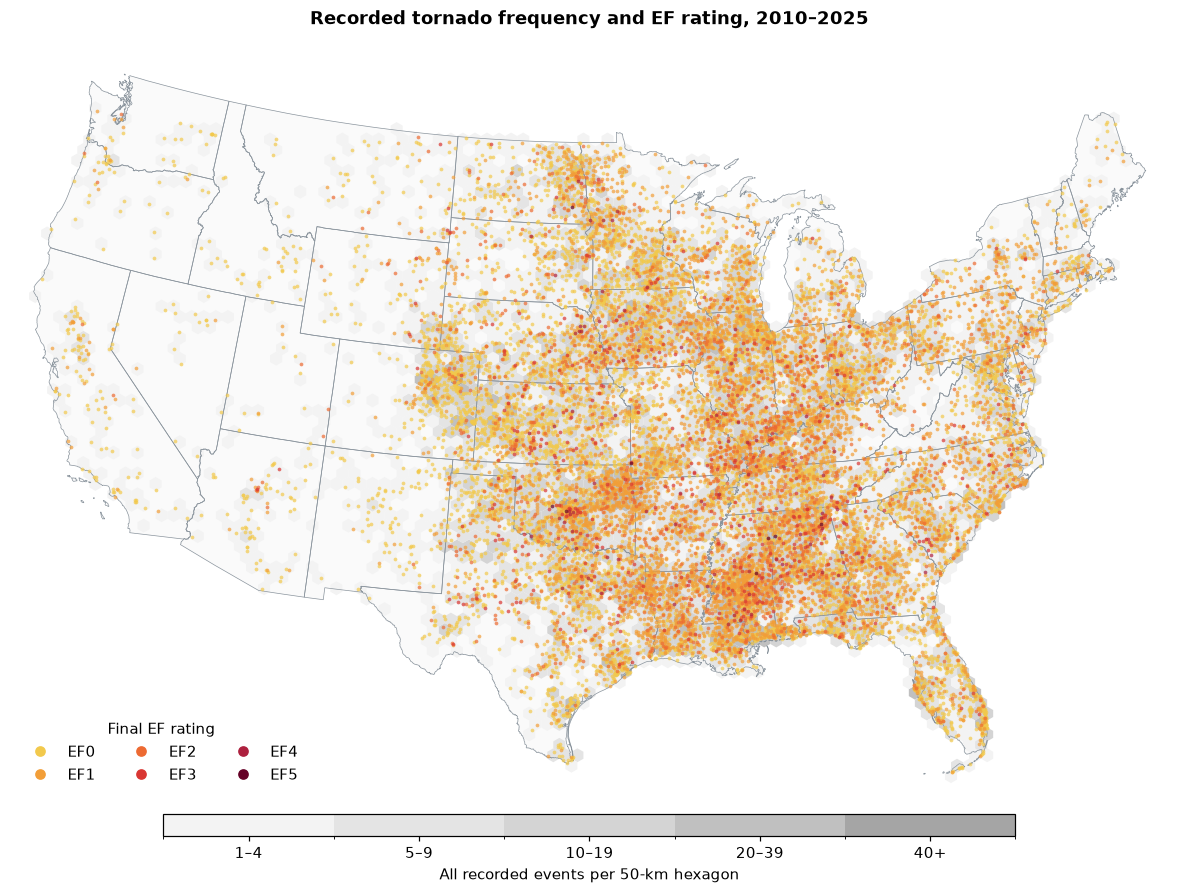

**Figure 2.** Contiguous-U.S. event starts, colored separately for EF0–EF5, over recorded counts in equal-area hexagons approximately 50 km across. Stronger ratings are drawn last; overlap can hide points. Unknown ratings contribute to counts only. These are catalog counts, not estimates of local tornado risk.

**Saved — figure:** [fig_02_geographic_distribution.png](assets/figures/fig_02_geographic_distribution.png) · [fig_02_geographic_distribution.svg](assets/figures/fig_02_geographic_distribution.svg)

In [12]:
counties = gpd.read_parquet(SOURCE_DIR / "analysis/county_boundaries.parquet")
event_areas = gpd.read_parquet(SOURCE_DIR / "analysis/event_areas.parquet").set_index(ID)
assert event_areas.index.is_unique and set(event_areas.index) == set(onset[ID])
map_events = onset[[ID, TARGET, "start_longitude", "start_latitude", "target_known"]].copy()
map_events["state_fips"] = map_events[ID].map(event_areas["state_fips"])
# Restrict the displayed maps only; the modeling cohort remains unchanged.
conus_mask = ~map_events.state_fips.isin(["02", "15", "60", "66", "69", "72", "78"])
map_events = map_events.loc[conus_mask].copy()
assert map_events[["start_longitude", "start_latitude", "state_fips"]].notna().all().all()
events = gpd.GeoDataFrame(
    map_events,
    geometry=gpd.points_from_xy(map_events.start_longitude, map_events.start_latitude),
    crs="EPSG:4326",
).to_crs("EPSG:5070")
boundaries = counties.loc[
    counties.state_fips.isin(map_events.state_fips), ["state_fips", "geometry"]
]
boundaries = boundaries.dissolve("state_fips").to_crs(events.crs)
cells, extent = geographic_bins(events, boundaries, hex_width_m=50_000)
fig = plot_geographic_distribution(
    events,
    boundaries,
    cells,
    extent,
    class_names=CLASS_NAMES,
    colors=EF_COLORS,
)
show_figure(
    fig,
    "fig_02_geographic_distribution",
    "**Figure 2.** Contiguous-U.S. event starts, colored separately for EF0–EF5, over recorded counts in equal-area hexagons approximately 50 km across. Stronger ratings are drawn last; overlap can hide points. Unknown ratings contribute to counts only. These are catalog counts, not estimates of local tornado risk.",
)

## 4. Analysis Preparation

Preserve **EF0–EF5** and use a shared, group-aware stratified random split targeting
**70% training, 15% validation, and 15% testing**. Keep linked events together and
exclude unknown ratings from supervised analysis. Report achieved class support;
class weights cannot compensate for the limited independent EF5 examples.

Explore training relationships before preparing the two feature views. Encode month
and hour cyclically and log-transform selected skewed predictors. Fit median imputation,
missingness indicators, scaling, and class weights on **training data only**, using the
same rules and event assignments for both views. Reserve test scoring for final models.

A temporal split is a later robustness check; focal loss and ordinal classification are
separate extensions. The Oklahoma footprint is a supporting illustration of track geometry.
Saved outputs are linked below their corresponding results.

### Cohort and target

In [13]:
PREPARATION_DIR = RESULTS_DIR / "preparation"
PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
eligible = onset.loc[onset.target_known].reset_index(drop=True)
ratings = eligible[TARGET].to_numpy(dtype=int)
group_ids = eligible[GROUP].to_numpy()


chosen_split = stratified_group_holdout(
    ratings,
    group_ids,
    fractions=SPLIT_FRACTIONS,
    class_count=N_CLASSES,
    seed=SEED,
    candidates=SPLIT_CANDIDATES,
)
split_lookup = pd.Series(
    {
        event_id: split
        for split, indices in zip(SPLIT_ORDER, chosen_split["indices"], strict=True)
        for event_id in eligible.iloc[indices][ID]
    }
)
assignments = onset[[ID, GROUP, "onset_utc", "target_known"]].copy()
assignments["eligible"] = assignments.target_known
assignments["split"] = assignments[ID].map(split_lookup).fillna("excluded")
assignments["exclusion_reason"] = np.where(assignments.target_known, "", "unknown_label")
assert assignments.loc[assignments.target_known, "split"].isin(SPLIT_ORDER).all()
assert assignments.loc[~assignments.target_known, "split"].eq("excluded").all()
assignments.to_parquet(DERIVED_DIR / "split_assignments.parquet", index=False)
split_ids = {
    split: assignments.loc[assignments.split.eq(split), ID].tolist() for split in SPLIT_ORDER
}
split_groups = {
    split: set(assignments.loc[assignments.split.eq(split), GROUP]) for split in SPLIT_ORDER
}
for i, first in enumerate(SPLIT_ORDER):
    for second in SPLIT_ORDER[i + 1 :]:
        assert set(split_ids[first]).isdisjoint(split_ids[second])
        assert split_groups[first].isdisjoint(split_groups[second])
assert sum(map(len, split_ids.values())) == len(eligible)
indexed_tables = {view: frame.set_index(ID) for view, frame in tables.items()}
cohorts = {
    view: {split: frame.loc[split_ids[split]].copy() for split in SPLIT_ORDER}
    for view, frame in indexed_tables.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_series_equal(
        cohorts["Onset"][split][TARGET], cohorts["Retrospective"][split][TARGET]
    )
    assert set(cohorts["Onset"][split][TARGET].unique()) == set(range(N_CLASSES))

split_summary = pd.DataFrame(
    [
        {
            "Split": split.title(),
            "Target (%)": 100 * fraction,
            "Events": len(split_ids[split]),
            "Actual (%)": 100 * len(split_ids[split]) / len(eligible),
            "Groups": len(split_groups[split]),
        }
        for split, fraction in zip(SPLIT_ORDER, SPLIT_FRACTIONS, strict=True)
    ]
)
save_json(
    {
        "method": "seeded group-random candidate search with class stratification objective",
        "seed": SEED,
        "candidate_count": SPLIT_CANDIDATES,
        "chosen_candidate": chosen_split["candidate"],
        "balance_score": chosen_split["score"],
        "selection_basis": "equal-weight class-allocation MSE plus row-allocation MSE; all six classes required",
        "target_fractions": dict(zip(SPLIT_ORDER, SPLIT_FRACTIONS.tolist(), strict=True)),
        "unknown_labels_excluded": int((~assignments.target_known).sum()),
        "retained_events": {s: len(ids) for s, ids in split_ids.items()},
        "retained_groups": {s: len(groups) for s, groups in split_groups.items()},
        "group_overlap": False,
    },
    PREPARATION_DIR / "split_summary.json",
)
save_json(EVALUATION_SETTINGS, DERIVED_DIR / "evaluation_config.json")
show_saved(
    f"{len(eligible):,} labeled events assigned to disjoint groups across splits",
    DERIVED_DIR / "split_assignments.parquet",
    PREPARATION_DIR / "split_summary.json",
)
show_saved("metrics and held-out evaluation rules", DERIVED_DIR / "evaluation_config.json")

**Saved — 18,639 labeled events assigned to disjoint groups across splits:** [split_assignments.parquet](data/derived/split_assignments.parquet) · [split_summary.json](data/results/preparation/split_summary.json)

**Saved — metrics and held-out evaluation rules:** [evaluation_config.json](data/derived/evaluation_config.json)

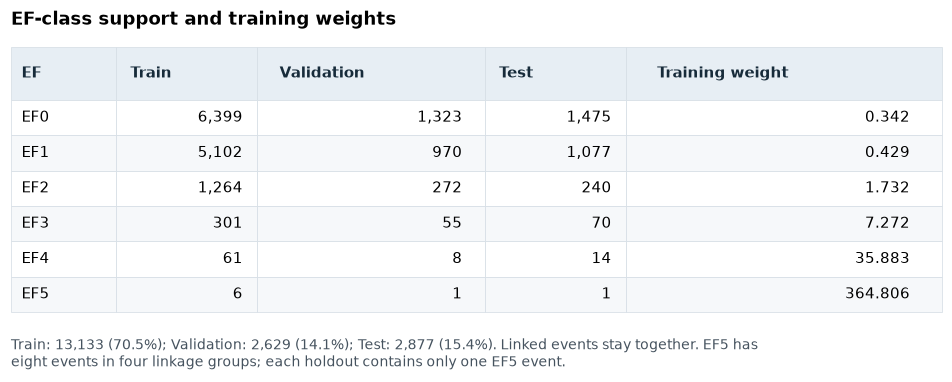

**Table 1.** Shared split assignments and training-only class weights for both feature views.

**Saved — EF-class support and training weights:** [table_01_class_support.png](assets/tables/table_01_class_support.png) · [table_01_class_support.svg](assets/tables/table_01_class_support.svg) · [table_01_class_support.csv](data/results/preparation/table_01_class_support.csv)

**Saved — aligned labels for train, validation, and test:** [labels_train.parquet](data/derived/labels_train.parquet) · [labels_validation.parquet](data/derived/labels_validation.parquet) · [labels_test.parquet](data/derived/labels_test.parquet)

**Saved — six-class target definition and training weights:** [target_definition.json](data/derived/target_definition.json) · [class_weights.json](data/derived/class_weights.json)

In [14]:
class_support = pd.DataFrame(
    {
        split.title(): cohorts["Onset"][split][TARGET]
        .value_counts()
        .reindex(range(N_CLASSES), fill_value=0)
        for split in SPLIT_ORDER
    }
)
support_table = class_support.rename_axis("EF").reset_index()
support_table["EF"] = support_table.EF.map(lambda rating: CLASS_NAMES[rating])
TARGET_MAPPING = {rating: rating for rating in range(N_CLASSES)}
y = {
    split: cohorts["Onset"][split][TARGET].astype("int64").rename("target_class")
    for split in SPLIT_ORDER
}
for split in SPLIT_ORDER:
    assert set(y[split].unique()) == set(range(N_CLASSES))
    pd.concat([cohorts["Onset"][split][TARGET], y[split]], axis=1).to_parquet(
        DERIVED_DIR / f"labels_{split}.parquet"
    )
save_json(
    {
        "source_target": TARGET,
        "mapping": {str(k): v for k, v in TARGET_MAPPING.items()},
        "class_names": CLASS_NAMES,
        "n_classes": N_CLASSES,
        "rationale": "Preserve each original EF category; class collapsing is not the default.",
        "unknown_labels": "excluded from supervised learning, retained in coverage summaries",
        "planned_output": "six-class softmax",
        "planned_loss": "class-weighted sparse categorical cross-entropy",
        "selection_metric_for_later_models": "validation macro-F1 across all six labels",
        "rare_class_limitation": "Class weighting does not create additional independent EF5 evidence.",
    },
    DERIVED_DIR / "target_definition.json",
)

class_weights = dict(
    zip(
        range(N_CLASSES),
        compute_class_weight(
            class_weight="balanced", classes=np.arange(N_CLASSES), y=y["train"].to_numpy()
        ).tolist(),
        strict=True,
    )
)
save_json(
    {
        "strategy": "balanced class weights for six-class cross-entropy; no resampling",
        "weights": {str(k): v for k, v in class_weights.items()},
        "formula": "n_training / (n_classes * class_training_count)",
        "policy": "hold weights fixed across controlled experiments; validation/test metrics unweighted",
    },
    DERIVED_DIR / "class_weights.json",
)

support_table["Training weight"] = [class_weights[i] for i in range(N_CLASSES)]
split_note = "; ".join(
    f"{row['Split']}: {row['Events']:,} ({row['Actual (%)']:.1f}%)"
    for row in split_summary.to_dict("records")
)
save_table(
    support_table,
    "table_01_class_support",
    "EF-class support and training weights",
    caption="**Table 1.** Shared split assignments and training-only class weights for both feature views.",
    formats={**{split.title(): ",d" for split in SPLIT_ORDER}, "Training weight": ".3f"},
    note=split_note + ". Linked events stay together. EF5 has eight events in four linkage groups; "
    "each holdout contains only one EF5 event.",
    width=9,
    results_dir=PREPARATION_DIR,
)

show_saved(
    "aligned labels for train, validation, and test",
    *(DERIVED_DIR / f"labels_{split}.parquet" for split in SPLIT_ORDER),
)
show_saved(
    "six-class target definition and training weights",
    DERIVED_DIR / "target_definition.json",
    DERIVED_DIR / "class_weights.json",
)

### Training-data exploration

In [15]:
train = cohorts["Retrospective"]["train"]
train_numeric = train[predictors["Retrospective"]].select_dtypes(include="number")
training_skew = train_numeric.skew()

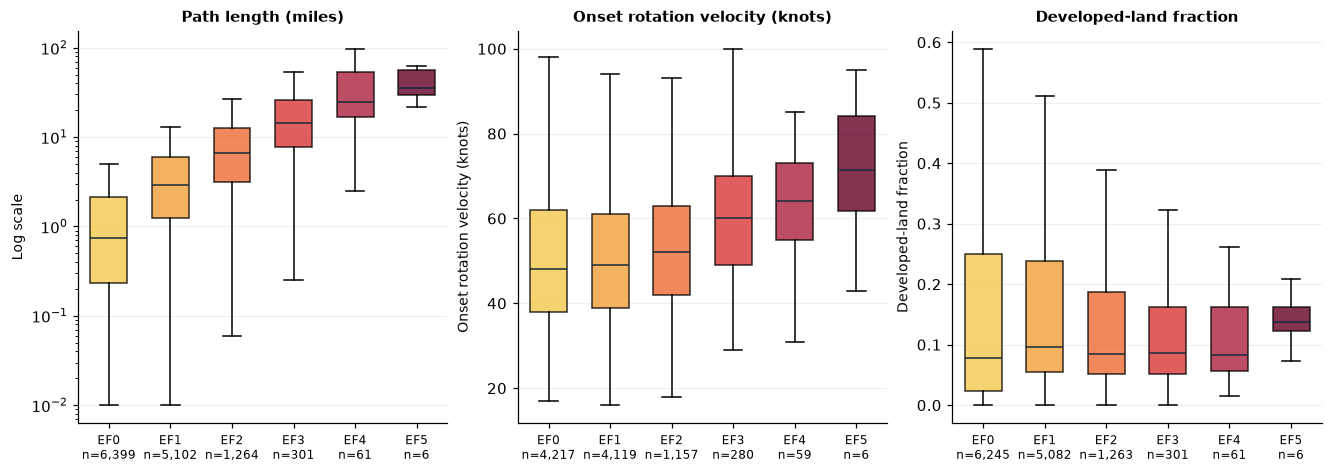

**Figure 3.** Training predictors by original EF rating. Boxes show medians and interquartile ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed values for that feature; rare-class and missing-data patterns limit interpretation.

**Saved — figure:** [fig_03_training_relationships.png](assets/figures/fig_03_training_relationships.png) · [fig_03_training_relationships.svg](assets/figures/fig_03_training_relationships.svg)

In [16]:
relationship_features = [
    ("post_path_length_miles", "Path length (miles)", True),
    ("radar_max_rotation_velocity_knots", "Onset rotation velocity (knots)", False),
    ("post_land_developed_fraction", "Developed-land fraction", False),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained")
for ax, (feature, label, log_axis) in zip(axes.flat, relationship_features, strict=True):
    values = [
        train.loc[train[TARGET].eq(ef), feature].dropna().to_numpy(dtype=float) for ef in range(6)
    ]
    boxes = ax.boxplot(
        values,
        tick_labels=[f"EF{ef}\nn={len(v):,}" for ef, v in enumerate(values)],
        patch_artist=True,
        showfliers=False,
        widths=0.6,
    )
    for ef, box in enumerate(boxes["boxes"]):
        box.set_facecolor(EF_COLORS[f"EF{ef}"])
        box.set_alpha(0.8)
    for median in boxes["medians"]:
        median.set_color("#172B3A")
    if log_axis:
        ax.set_yscale("log")
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Log scale" if log_axis else label, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_03_training_relationships",
    "**Figure 3.** Training predictors by original EF rating. Boxes show medians and interquartile ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed values for that feature; rare-class and missing-data patterns limit interpretation.",
)

### Feature preparation

In [17]:
feature_groups = {
    "Location and timing": ["start_longitude", "start_latitude", "month", "hour_utc"],
    "Onset radar": [c for c in predictors["Onset"] if c.startswith("radar_")],
    "Warnings": [c for c in predictors["Onset"] if c.startswith("warning_")],
    "Final track": [
        "post_end_longitude",
        "post_end_latitude",
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
    ],
    "Full-window radar": [c for c in predictors["Retrospective"] if c.startswith("post_radar_")],
    "Land cover": [
        c
        for c in predictors["Retrospective"]
        if c.startswith("post_land_") or c == "post_impervious_mean_percent"
    ],
}
group_columns = [c for columns in feature_groups.values() for c in columns]
assert len(group_columns) == len(set(group_columns))
assert set(group_columns) == set(predictors["Retrospective"])

group_summary = pd.DataFrame(
    [
        {
            "Feature group": group,
            "Onset": len(set(columns) & set(predictors["Onset"])),
            "Retrospective": len(columns),
        }
        for group, columns in feature_groups.items()
    ]
)

# The source stores hour 0–23 as epoch nanoseconds; derive hours from onset_utc.
for frame in tables.values():
    assert pd.api.types.is_datetime64_any_dtype(frame["hour_utc"])
    encoded_hour = frame["hour_utc"].astype("int64")
    assert encoded_hour.between(0, 23).all()
    np.testing.assert_array_equal(encoded_hour, frame["onset_utc"].dt.hour)
    np.testing.assert_array_equal(frame["month"], frame["onset_utc"].dt.month)

log_candidates = [
    c
    for c in predictors["Retrospective"]
    if ("radar_" in c and c.endswith("_count"))
    or c
    in [
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
        "post_impervious_mean_percent",
    ]
]
LOG_COLUMNS = [c for c in log_candidates if training_skew[c] > 1]
assert train[LOG_COLUMNS].min().ge(0).all()


encoded = {
    view: {
        split: encode_predictors(frame, predictors[view], log_columns=LOG_COLUMNS)
        for split, frame in split_frames.items()
    }
    for view, split_frames in cohorts.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_frame_equal(
        encoded["Onset"][split],
        encoded["Retrospective"][split][encoded["Onset"][split].columns],
    )
predictor_definition = {
    "raw_columns": predictors,
    "groups": feature_groups,
    "encoded_columns": {view: frame["train"].columns.tolist() for view, frame in encoded.items()},
    "log1p_columns": LOG_COLUMNS,
    "log_selection": "nonnegative count/track/impervious candidates with training skew > 1",
    "calendar_encoding": "month and UTC hour replaced by sine/cosine pairs",
    "hour_correction": "derive numeric hour from onset_utc; verified against stored epoch-nanosecond values",
    "source_files_modified": False,
}
save_json(predictor_definition, DERIVED_DIR / "predictor_sets.json")
show_saved(
    f"feature definitions, cyclic time encoding, and {len(LOG_COLUMNS)} log transforms",
    DERIVED_DIR / "predictor_sets.json",
)

**Saved — feature definitions, cyclic time encoding, and 10 log transforms:** [predictor_sets.json](data/derived/predictor_sets.json)

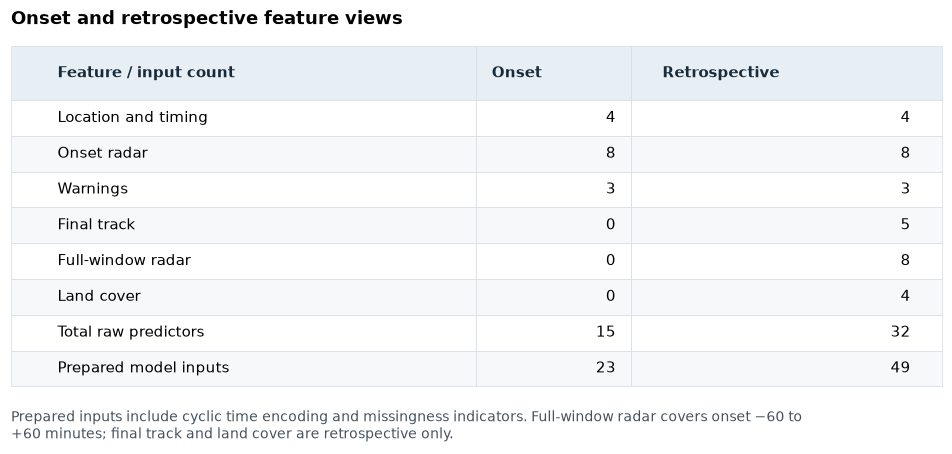

**Table 2.** Feature-group counts and final input dimensions for the same event cohort.

**Saved — Onset and retrospective feature views:** [table_02_feature_views.png](assets/tables/table_02_feature_views.png) · [table_02_feature_views.svg](assets/tables/table_02_feature_views.svg) · [table_02_feature_views.csv](data/results/preparation/table_02_feature_views.csv)

**Saved — Onset inputs — 23 columns; train: 13,133 rows, validation: 2,629 rows, test: 2,877 rows:** [onset_train.parquet](data/derived/onset_train.parquet) · [onset_validation.parquet](data/derived/onset_validation.parquet) · [onset_test.parquet](data/derived/onset_test.parquet)

**Saved — Retrospective inputs — 49 columns; train: 13,133 rows, validation: 2,629 rows, test: 2,877 rows:** [retrospective_train.parquet](data/derived/retrospective_train.parquet) · [retrospective_validation.parquet](data/derived/retrospective_validation.parquet) · [retrospective_test.parquet](data/derived/retrospective_test.parquet)

**Saved — fitted training-only imputation and scaling pipelines:** [onset_preprocessor.joblib](data/derived/onset_preprocessor.joblib) · [retrospective_preprocessor.joblib](data/derived/retrospective_preprocessor.joblib)

**Saved — preprocessing settings and input column order:** [preprocessing_config.json](data/derived/preprocessing_config.json)

In [18]:
preprocessors: dict[str, Pipeline] = {}
X: dict[str, dict[str, pd.DataFrame]] = {}
for view, split_frames in encoded.items():
    preprocessor, prepared_splits = prepare_inputs(split_frames, y)
    preprocessors[view], X[view] = preprocessor, prepared_splits
    for split, prepared in prepared_splits.items():
        prepared.to_parquet(DERIVED_DIR / f"{view.lower()}_{split}.parquet")
    joblib.dump(preprocessor, DERIVED_DIR / f"{view.lower()}_preprocessor.joblib")

save_json(
    {
        "fit_split": "train",
        "imputation": "training median",
        "missing_indicators": "columns with missing values in training",
        "scaling": "training mean and standard deviation, including indicators",
        "raw_predictors": predictors,
        "log1p_columns": LOG_COLUMNS,
        "input_columns": {
            view: split_frames["train"].columns.tolist() for view, split_frames in X.items()
        },
        "training_id_sha256": hashlib.sha256("\n".join(split_ids["train"]).encode()).hexdigest(),
        "sklearn_version": version("scikit-learn"),
        "split_method": "group-aware stratified random holdout",
        "seed": SEED,
    },
    DERIVED_DIR / "preprocessing_config.json",
)

view_summary = pd.concat(
    [
        group_summary.rename(columns={"Feature group": "Feature / input count"}),
        pd.DataFrame(
            [
                {
                    "Feature / input count": "Total raw predictors",
                    **{view: len(columns) for view, columns in predictors.items()},
                },
                {
                    "Feature / input count": "Prepared model inputs",
                    **{view: frames["train"].shape[1] for view, frames in X.items()},
                },
            ]
        ),
    ],
    ignore_index=True,
)
save_table(
    view_summary,
    "table_02_feature_views",
    "Onset and retrospective feature views",
    caption="**Table 2.** Feature-group counts and final input dimensions for the same event cohort.",
    formats={"Onset": "d", "Retrospective": "d"},
    width=9,
    note="Prepared inputs include cyclic time encoding and missingness indicators. Full-window radar "
    "covers onset −60 to +60 minutes; final track and land cover are retrospective only.",
    results_dir=PREPARATION_DIR,
)

for view, frames in X.items():
    sizes = ", ".join(f"{split}: {len(frames[split]):,} rows" for split in SPLIT_ORDER)
    show_saved(
        f"{view} inputs — {frames['train'].shape[1]} columns; {sizes}",
        *(DERIVED_DIR / f"{view.lower()}_{split}.parquet" for split in SPLIT_ORDER),
    )
show_saved(
    "fitted training-only imputation and scaling pipelines",
    *(DERIVED_DIR / f"{view.lower()}_preprocessor.joblib" for view in X),
)
show_saved(
    "preprocessing settings and input column order", DERIVED_DIR / "preprocessing_config.json"
)

### Supporting event illustration

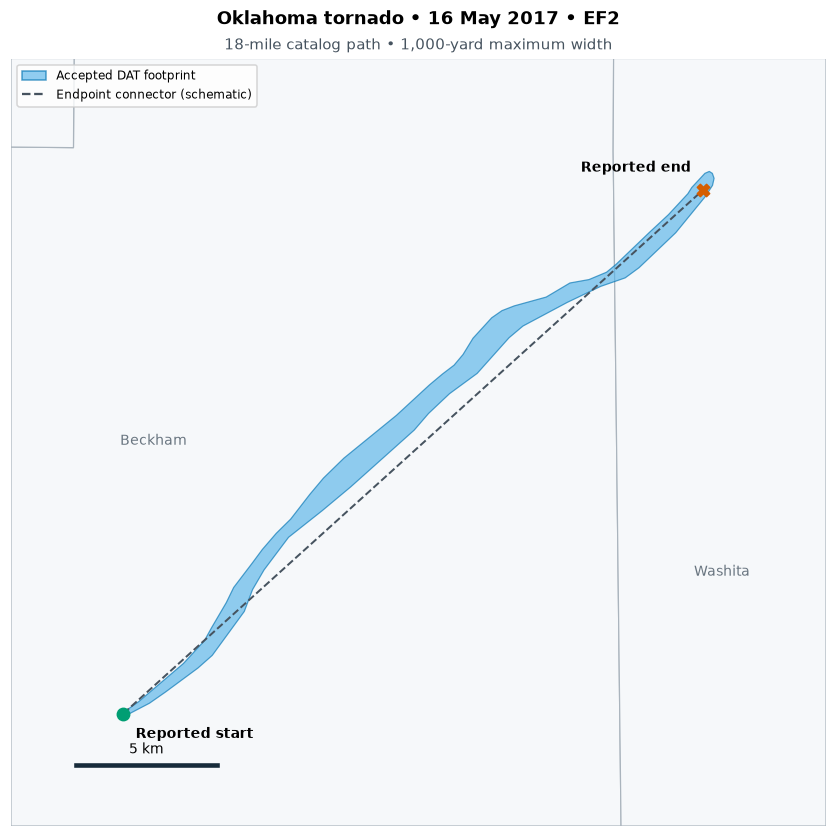

**Figure 4 (supporting).** Training event `spc:2017:1705161746-01` and its accepted DAT footprint. The dashed connector joins SPC start/end coordinates; it is not a surveyed centerline. The footprint does not show a time-resolved trajectory or local EF changes. This fixed Oklahoma example is illustrative and was not used to choose the split or model settings.

**Saved — figure:** [fig_04_example_event_footprint.png](assets/figures/fig_04_example_event_footprint.png) · [fig_04_example_event_footprint.svg](assets/figures/fig_04_example_event_footprint.svg)

In [19]:
footprints = gpd.read_parquet(SOURCE_DIR / "analysis/tornado_footprints.parquet").set_index(
    "footprint_id"
)
assert footprints.index.is_unique
# Keep the previously illustrated event; it must belong to the shared training split.
example_id = "spc:2017:1705161746-01"
assert example_id in split_ids["train"]
example = train.loc[example_id]
area = event_areas.loc[[example_id]]
footprint_ids = area.iloc[0].footprint_ids.tolist()
assert area.iloc[0].area_method == "union_of_accepted_footprints"
assert example_id in split_ids["train"] and area.iloc[0].state_fips == "40"
local_crs = area.estimate_utm_crs()
footprint = footprints.loc[footprint_ids].to_crs(local_crs)
endpoints = gpd.GeoSeries(
    gpd.points_from_xy(
        [example.start_longitude, example.post_end_longitude],
        [example.start_latitude, example.post_end_latitude],
    ),
    crs="EPSG:4326",
).to_crs(local_crs)
assert not endpoints.is_empty.any()
all_bounds = np.vstack([footprint.total_bounds, endpoints.total_bounds])
low, high = all_bounds[:, :2].min(axis=0) - 4_000, all_bounds[:, 2:].max(axis=0) + 4_000
window = geometry_box(*low, *high)
local_counties = counties.loc[counties.state_fips.isin(area.iloc[0].area_states)].to_crs(local_crs)
local_counties = local_counties.clip(window)

fig, ax = plt.subplots(figsize=(8, 7.5), layout="constrained")
local_counties.plot(ax=ax, color="#F6F8FA", edgecolor="#AAB4BD", linewidth=0.8)
for _, county in local_counties.iterrows():
    if county.geometry.area < window.area * 0.03:
        continue
    label_area = county.geometry.difference(footprint.geometry.union_all().buffer(1_500))
    center = label_area.representative_point()
    ax.text(center.x, center.y, county.county_name, ha="center", fontsize=9, color="#697580")
footprint.plot(ax=ax, color="#56B4E9", alpha=0.65, edgecolor=ACCENT, linewidth=0.8)
ax.plot(endpoints.x, endpoints.y, "--", color="#46535F", linewidth=1.3)
ax.scatter(endpoints.x.iloc[0], endpoints.y.iloc[0], color="#009E73", s=65, marker="o", zorder=5)
ax.scatter(endpoints.x.iloc[1], endpoints.y.iloc[1], color="#D55E00", s=65, marker="X", zorder=5)
for i, label in enumerate(["Reported start", "Reported end"]):
    ax.annotate(
        label,
        (endpoints.x.iloc[i], endpoints.y.iloc[i]),
        xytext=(8, -16) if i == 0 else (-8, 12),
        textcoords="offset points",
        ha="left" if i == 0 else "right",
        fontsize=9,
        weight="bold",
    )
bar_x, bar_y = low + (high - low) * [0.08, 0.08]
ax.plot([bar_x, bar_x + 5_000], [bar_y, bar_y], color="#172B3A", linewidth=3)
ax.text(bar_x + 2_500, bar_y + 400, "5 km", ha="center", fontsize=9)
ax.set(xlim=(low[0], high[0]), ylim=(low[1], high[1]))
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(
    f"{example.post_path_length_miles:.0f}-mile catalog path • "
    f"{example.post_path_width_yards:,.0f}-yard maximum width",
    fontsize=10,
    weight="normal",
    color="#46535F",
)
ax.legend(
    handles=[
        Patch(facecolor="#56B4E9", edgecolor=ACCENT, alpha=0.65, label="Accepted DAT footprint"),
        Line2D([0], [0], color="#46535F", linestyle="--", label="Endpoint connector (schematic)"),
    ],
    loc="upper left",
    frameon=True,
    fontsize=8,
)
state_name = counties.loc[counties.state_fips.eq(area.iloc[0].state_fips), "state_name"].iloc[0]
fig.suptitle(
    f"{state_name} tornado • {example.onset_utc:%d %B %Y} • EF{int(example[TARGET])}", weight="bold"
)
show_figure(
    fig,
    "fig_04_example_event_footprint",
    f"**Figure 4 (supporting).** Training event `{example_id}` and its accepted DAT footprint. The dashed connector joins SPC start/end coordinates; it is not a surveyed centerline. The footprint does not show a time-resolved trajectory or local EF changes. This fixed Oklahoma example is illustrative and was not used to choose the split or model settings.",
)

## 5. Neural-Network Experiments

Address the **modeling question** through controlled TensorFlow/Keras comparisons
on the retrospective task, holding preprocessing, splits, seeds, and unrelated
training settings fixed.

| Experiment | Comparison |
|---|---|
| Baseline | At least three hidden ReLU Dense layers; no L1/L2 or dropout |
| SGD | Learning rates 0.1, 0.01, and 0.001 |
| L2 | Baseline versus L2 on hidden layers, starting at 0.001 |
| Dropout | Rates 0.0, 0.2, and 0.5 at fixed positions, without L2 |

Keep the optimizer and learning rate matched within L2 and dropout comparisons.
Use training/validation metrics and learning curves to assess learning speed,
overfitting, and generalization.

## 6. Research Experiments

Address the **primary question** by comparing retrospective feature groups, including
sensitivity to final track and damage-derived inputs. Address the **secondary question**
by retraining the selected approach on onset predictors. Compare validation performance
by class on the same event splits.

The analysis for the secondary question is conditional on cataloged onset and location, with an
assumed five-minute radar latency; actual real-time availability is unverified.
Final track measurements and footprint-based land cover are excluded from onset
predictors because they depend on post-event information.

A later temporal robustness check refits preprocessing and retrains the same approach
on earlier years. Focal loss and ordinal classification are separate comparisons.

## 7. Final Evaluation

Evaluate each selected model once on the held-out test set. Report accuracy,
cross-entropy, macro-F1, per-class precision/recall/F1, class support, and a
six-class confusion matrix. Also report mean absolute EF-category error and
within-one-category accuracy using the predicted class.

Keep all six labels in metric summaries, explicitly flagging absent or very rare
classes. Examine errors and unusual cases without using test results to revise
the model. Temporal robustness and alternative losses remain separate analyses.

## 8. Findings and Limitations

Answer the **primary question**, **secondary question**, and **modeling question**.
Discuss uncertainty from rare classes,
unknown labels, missingness, source linkage, and temporal transfer, and identify
next steps. Interpret feature contributions as associations; model disagreement
alone does not establish causation or an incorrect EF rating.